In [48]:
import rasterio
import rasterio.features
from rasterio.mask import mask
from rasterio.features import shapes
from rasterio.features import rasterize
from torch import nn
import torch
from osgeo import ogr
import geopandas as gpd
import pandas as pd

pd.options.mode.copy_on_write = True
from shapely.geometry import shape
from shapely.geometry import box
from scipy import ndimage
import matplotlib.pyplot as plt
import numpy as np
import os
import tqdm
from concurrent.futures import ProcessPoolExecutor
import datetime
import glob
DISABLE_PBAR = True

In [6]:
tucker_niger = rasterio.open("/mnt/sdc/tree_density_and_coverage/tucker_tree_density_niger.tif").read(5)
maradi = rasterio.open("/mnt/sdc/tree_density_and_coverage/tucker_tree_density_maradi.tif").read(5)

In [7]:
tucker_niger = np.where(tucker_niger == 65535, 0, tucker_niger)
maradi = np.where(maradi == 65535, 0, maradi)

In [8]:
print(tucker_niger.sum())
print(maradi.sum())


545675693
60186710


In [49]:
tiles = gpd.read_file(f"/mnt/sdc/tree_density_and_coverage/shapefiles/ls_downloading/merged_agro.gpkg")
tiles_filt = tiles.dropna()
qnap_dir = "/media/rene1337/27e47104-4197-4926-a3d0-101c850014fe"

In [50]:
def get_raster_pixel_polygon(points_gdf, reference_raster, crs="EPSG:4326"):
    points_gdf = points_gdf.to_crs(crs)
    bounds = points_gdf.total_bounds
    src = rasterio.open(reference_raster)
    wn = rasterio.windows.from_bounds(*bounds, transform=src.transform)
    wn_transform = rasterio.windows.transform(wn, src.transform)
    rst  = src.read(1)
    rst = np.random.uniform(size=rst.shape).astype(np.float32)
    feats = rasterio.features.shapes(rst, mask=None, transform=src.transform)
    polys = [(shape(feat[0])) for feat in tqdm.tqdm(feats, total=(rst.shape[0]*rst.shape[1]), disable=DISABLE_PBAR)]
    df = gpd.GeoDataFrame(polys, columns=['geometry'], crs=crs)
    return df, wn, wn_transform, src
 

def get_tree_count(points_gdf, raster_gdf):
    points_gdf = points_gdf.to_crs(raster_gdf.crs)
    raster_gdf['OBJECTID'] = raster_gdf.index
    df_count = raster_gdf.merge(
    raster_gdf.sjoin(
        points_gdf
    ).groupby(
        'OBJECTID',
    ).count().geometry.rename(
        'value',
    ).reset_index())
    return df_count


def burn_vector(image_path, src, vector, name):
    meta = src.meta.copy()
    meta.update({
        'width': src.width,
        'height': src.height,
        'transform': src.transform,
        'crs': src.crs,
        'dtype': np.float32,
        'count': 1
    })
    
    with rasterio.open(f"{name}.tif", 'w', **meta) as out:
        out_arr = np.zeros((src.height, src.width), dtype=np.float32)
        
        vector = vector.to_crs("EPSG:4326")
        
        # Create a generator of geom, value pairs to use in rasterizing
        shapes = ((geom, value) for geom, value in zip(vector.geometry, vector[name]))
        
        # Perform rasterization
        burned = rasterize(
            shapes=shapes,
            out=out_arr,
            transform=src.transform,
            fill=0,
            all_touched=True,  # Ensure all touched pixels are burned
            dtype=np.float32
        )
        
        out.write(burned, 1)
        
        return burned
    

def calculate_tree_statistics(tree_gdf, raster_gdf, crs="EPSG:4326"):
    """
    Calculate statistics of tree polygon area and add it to the raster grid where they intersect.
    
    Parameters:
    - tree_gdf (GeoDataFrame): GeoDataFrame containing tree polygons.
    - raster_gdf (GeoDataFrame): GeoDataFrame containing raster grid.
    - crs (str): Coordinate reference system to use for the calculations.
    
    Returns:
    - raster_gdf (GeoDataFrame): Updated raster GeoDataFrame with tree statistics.
    """
    # Ensure both GeoDataFrames are in the same CRS
    tree_gdf = tree_gdf.to_crs(crs)
    raster_gdf = raster_gdf.to_crs(crs)
    
    raster_gdf['OBJECTID'] = raster_gdf.index
    
    # Calculate the area of each tree polygon
    tree_gdf['area'] = tree_gdf.geometry.area
    
    # Find the intersection of the tree polygons and the raster grid
    intersection_gdf = gpd.overlay(raster_gdf, tree_gdf, how='intersection', keep_geom_type=False)
   
    # Reset index to ensure proper indexing
    intersection_gdf = intersection_gdf.reset_index()
    
    # Calculate the area of each intersection
    intersection_gdf['intersection_area'] = intersection_gdf.geometry.area
    
    # Add a column with the index of the corresponding polygon in raster_gdf
    intersection_gdf['raster_index'] = intersection_gdf['OBJECTID']
    
    # Group by the raster grid index and calculate statistics
    stats = intersection_gdf.groupby('raster_index').agg(
        tree_count=('geometry', 'count'),
        total_tree_area=('intersection_area', 'sum'),
        mean_tree_area=('intersection_area', 'mean'),
        max_tree_area=('intersection_area', 'max'),
        min_tree_area=('intersection_area', 'min'),
        std_tree_area=('intersection_area', 'std'),
        var_tree_area=('intersection_area', 'var')
    ).reset_index()
    
    # Merge the statistics back into the raster GeoDataFrame
    raster_gdf = raster_gdf.merge(stats, left_index=True, right_on='raster_index', how='left')
    
    # Fill NaN values with 0 (for areas with no trees)
    raster_gdf[['tree_count', 'total_tree_area', 'mean_tree_area', 'max_tree_area', 'min_tree_area']] = raster_gdf[['tree_count', 'total_tree_area', 'mean_tree_area', 'max_tree_area', 'min_tree_area']].fillna(0)
    
    return raster_gdf

In [63]:
for index, row in tqdm.tqdm(tiles_filt.iterrows(), total=tiles_filt.shape[0]):
    try:    
        utm = row["utm"]
        
        prediction_dir = f"{qnap_dir}/validation_predictions"
        polygons_dir = "/nfs/NASA/Tree_canopy_results_Tuckeretal/fixup_carbon"
        overwrite = True
        out_path = f"{qnap_dir}/valid_stats"
        os.makedirs(out_path, exist_ok=True)
        raster_file = row["tilename"]
        tile_id = row["tile_id_2"]
        
        if os.path.exists(f"{out_path}/{tile_id}_stats.tif"):
            print(f"File {tile_id}_stats.tif already exists")
            continue
        
        bounds = row.geometry.bounds

        bounds = tuple(gpd.GeoSeries(box(*bounds), crs="EPSG:3857").to_crs(f"EPSG:326{utm}").total_bounds)

        polygons_fp = f"{polygons_dir}/utm_{utm}/{raster_file[:-4]}/features.gpkg"
        
        landsat_path = f"{prediction_dir}/{tile_id}.tif"
        
        # check if path exists
        if not os.path.exists(landsat_path):
            #print(f"File {landsat_path} does not exist")
            continue
        
        polygons = gpd.read_file(polygons_fp, bbox=bounds, engine="pyogrio")

        raster_gdf, wn, wn_transform, src = get_raster_pixel_polygon(polygons, landsat_path)
        
        tree_stats = calculate_tree_statistics(polygons, raster_gdf, crs=f"EPSG:326{utm}")
        
        with rasterio.open(landsat_path) as src:
            rst = src.read()
            
            tree_count = burn_vector(out_path, src, tree_stats, name="tree_count")
            tree_area = burn_vector(out_path, src, tree_stats, name="total_tree_area")
            mean_tree_area = burn_vector(out_path, src,  tree_stats, name="mean_tree_area")
            max_tree_area = burn_vector(out_path, src,  tree_stats, name="max_tree_area")
            min_tree_area = burn_vector(out_path, src,  tree_stats, name="min_tree_area")
            std_tree_area = burn_vector(out_path, src,  tree_stats, name="std_tree_area")
            var_tree_area = burn_vector(out_path, src,  tree_stats, name="var_tree_area")
            
            out_meta = src.meta.copy()
            
            undetected_mask = np.where(rst[3] == 0, 1, 0)
            stats_array = np.stack([tree_count, tree_area, mean_tree_area, max_tree_area, 
                                    min_tree_area, std_tree_area, var_tree_area, undetected_mask], axis=0)
            
            rst[3] = rst[3] * 214
            rst[4] = rst[4] * 214
            
            out_array = np.concatenate([rst, stats_array], axis=0)
            
            out_meta.update({"count": out_array.shape[0]})
            
            with rasterio.open(f"{out_path}/{tile_id}_stats.tif", "w", **out_meta) as dst:
                #print(f"Wrote {out_path}/{tile_id}_stats.tif")
                dst.write(out_array)
    except Exception as e:
        print(e)
        continue

  0%|          | 79/88239 [00:00<13:32, 108.51it/s] 

File 34444_utm_28_stats.tif already exists
File 34652_utm_28_stats.tif already exists
File 34477_utm_28_stats.tif already exists
File 34482_utm_28_stats.tif already exists
File 34681_utm_28_stats.tif already exists
File 34663_utm_28_stats.tif already exists
File 34702_utm_28_stats.tif already exists
File 34481_utm_28_stats.tif already exists
File 34484_utm_28_stats.tif already exists
File 34483_utm_28_stats.tif already exists
File 34470_utm_28_stats.tif already exists
File 34472_utm_28_stats.tif already exists
File 34693_utm_28_stats.tif already exists
File 34692_utm_28_stats.tif already exists
File 34675_utm_28_stats.tif already exists
File 34674_utm_28_stats.tif already exists
File 34890_utm_28_stats.tif already exists
File 34889_utm_28_stats.tif already exists
File 42765_utm_28_stats.tif already exists
File 42760_utm_28_stats.tif already exists
File 42782_utm_28_stats.tif already exists
File 42893_utm_28_stats.tif already exists
File 42904_utm_28_stats.tif already exists
File 42900_

  0%|          | 307/88239 [00:01<03:34, 409.59it/s]

File 34755_utm_28_stats.tif already exists
File 34760_utm_28_stats.tif already exists
File 34774_utm_28_stats.tif already exists
File 34785_utm_28_stats.tif already exists
File 34915_utm_28_stats.tif already exists
File 34919_utm_28_stats.tif already exists
File 34921_utm_28_stats.tif already exists
File 34922_utm_28_stats.tif already exists
File 42791_utm_28_stats.tif already exists
File 42786_utm_28_stats.tif already exists
File 42774_utm_28_stats.tif already exists
File 42813_utm_28_stats.tif already exists
File 42812_utm_28_stats.tif already exists
File 42951_utm_28_stats.tif already exists
File 42940_utm_28_stats.tif already exists
File 42877_utm_28_stats.tif already exists
File 42885_utm_28_stats.tif already exists
File 42930_utm_28_stats.tif already exists
File 42867_utm_28_stats.tif already exists
File 42873_utm_28_stats.tif already exists
File 42916_utm_28_stats.tif already exists
File 42918_utm_28_stats.tif already exists
File 42913_utm_28_stats.tif already exists
File 42917_

  0%|          | 383/88239 [00:01<02:59, 490.62it/s]

...

 96%|█████████▌| 84347/88239 [24:21:29<45:00,  1.44it/s]   

File 46772_utm_36_stats.tif already exists


 96%|█████████▌| 84353/88239 [24:21:33<44:57,  1.44it/s]

File 46778_utm_36_stats.tif already exists


100%|██████████| 88239/88239 [25:21:34<00:00,  1.03s/it]  


In [64]:
raster_dir = "/media/rene1337/27e47104-4197-4926-a3d0-101c850014fe/valid_stats"

In [129]:
tiles["acqdate"] = pd.to_datetime(tiles["acqdate"])
tiles["year"] = tiles["acqdate"].dt.year
tiles_2012 = tiles[tiles["year"] <= 2012]
tiles_2020 = tiles[tiles["year"] >= 2014]


In [143]:
print(len(tiles_2012))
print(len(tiles_2020))

106971
115667


In [144]:
tiles_2012_id = tiles_2012["tile_id_2"].values
tiles_2020_id = tiles_2020["tile_id_2"].values
print(len(tiles_2012_id))
print(len(tiles_2020_id))

106971
115667


In [145]:
rasters = glob.glob(f"{raster_dir}/*.tif")
print(len(rasters))


11486


In [150]:
rasters_2012 = [r for r in rasters if os.path.basename(r).replace("_stats.tif", "") in tiles_2012_id]
print(len(rasters_2012))
rasters_2020 = [r for r in rasters if os.path.basename(r).replace("_stats.tif", "") in tiles_2020_id]
print(len(rasters_2020))


4411
5685


In [157]:
area_10_list = []
area_10_25_list = []
area_25_50_list = []
area_50_100_list = []
area_100_150_list = []
area_150_214_list = []

pred_10_list = []
pred_10_25_list = []
pred_25_50_list = []
pred_50_100_list = []
pred_100_150_list = []
pred_150_214_list = []
areas = []
preds = []


for raster in tqdm.tqdm(rasters_2020):
    with rasterio.open(raster) as src:
        rst = src.read()
        
        area = rst[6]
        pred = rst[4]
        
        # shift area 1 pixel to left and match to pred
        #area = np.roll(area, 1, axis=1)
        
        # crop both to (128, 128)
        area = area[:128, :128]
        pred = pred[:128, :128]
        
        area = np.sqrt(area)
        pred = np.sqrt(pred)
        
        areas.append(areas)
        preds.append(pred)
        
        pred_10 = np.where(area < 3, pred, 0)
        area_10 = np.where(area < 3, area, 0)
        
        pred_10_25 = np.where((area >= 3) & (area < 5), pred, 0)
        area_10_25 = np.where((area >= 3) & (area < 5), area, 0)
        
        pred_25_50 = np.where((area >= 5) & (area < 7), pred, 0)
        area_25_50 = np.where((area >= 5) & (area < 7), area, 0)
        
        pred_50_100 = np.where((area >= 7) & (area < 10), pred, 0)
        area_50_100 = np.where((area >= 7) & (area < 10), area, 0)
        
        pred_100_150 = np.where((area >= 10) & (area < 13), pred, 0)
        area_100_150 = np.where((area >= 10) & (area < 13), area, 0)
        
        pred_150_214 = np.where((area >= 13) & (area <= 15), pred, 0)
        area_150_214 = np.where((area >= 13) & (area <= 15), area, 0)
        
        pred_10_list.append(pred_10)
        area_10_list.append(area_10)
        
        pred_10_25_list.append(pred_10_25)
        area_10_25_list.append(area_10_25)
        
        pred_25_50_list.append(pred_25_50)
        area_25_50_list.append(area_25_50)
        
        pred_50_100_list.append(pred_50_100)
        area_50_100_list.append(area_50_100)
        
        pred_100_150_list.append(pred_100_150)
        area_100_150_list.append(area_100_150)
        
        pred_150_214_list.append(pred_150_214)
        area_150_214_list.append(area_150_214)

100%|██████████| 5685/5685 [00:12<00:00, 454.10it/s]


In [158]:
# FLATTENED LISTS

fl_pred_10 = np.nan_to_num(np.array([arr.flatten() for arr in pred_10_list]))
fl_area_10 = np.nan_to_num(np.array([arr.flatten() for arr in area_10_list]))

fl_pred_10_25 = np.nan_to_num(np.array([arr.flatten() for arr in pred_10_25_list]))
fl_area_10_25 = np.nan_to_num(np.array([arr.flatten() for arr in area_10_25_list]))

fl_pred_25_50 = np.nan_to_num(np.array([arr.flatten() for arr in pred_25_50_list]))
fl_area_25_50 = np.nan_to_num(np.array([arr.flatten() for arr in area_25_50_list]))

fl_pred_50_100 = np.nan_to_num(np.array([arr.flatten() for arr in pred_50_100_list]))
fl_area_50_100 = np.nan_to_num(np.array([arr.flatten() for arr in area_50_100_list]))

fl_pred_100_150 = np.nan_to_num(np.array([arr.flatten() for arr in pred_100_150_list]))
fl_area_100_150 = np.nan_to_num(np.array([arr.flatten() for arr in area_100_150_list]))

fl_pred_150_214 = np.nan_to_num(np.array([arr.flatten() for arr in pred_150_214_list]))
fl_area_150_214 = np.nan_to_num(np.array([arr.flatten() for arr in area_150_214_list]))


# STACKED ARRAYS

stacked_pred_10 = np.nan_to_num(np.array(pred_10_list))
stacked_area_10 = np.nan_to_num(np.array(area_10_list))

stacked_pred_10_25 = np.nan_to_num(np.array(pred_10_25_list))
stacked_area_10_25 = np.nan_to_num(np.array(area_10_25_list))

stacked_pred_25_50 = np.nan_to_num(np.array(pred_25_50_list))
stacked_area_25_50 = np.nan_to_num(np.array(area_25_50_list))

stacked_pred_50_100 = np.nan_to_num(np.array(pred_50_100_list))
stacked_area_50_100 = np.nan_to_num(np.array(area_50_100_list))

stacked_pred_100_150 = np.nan_to_num(np.array(pred_100_150_list))
stacked_area_100_150 = np.nan_to_num(np.array(area_100_150_list))

stacked_pred_150_214 = np.nan_to_num(np.array(pred_150_214_list))
stacked_area_150_214 = np.nan_to_num(np.array(area_150_214_list))



In [159]:
# means 
mean_pred_10 = np.sum(stacked_pred_10, axis=(1, 2))/10000
mean_area_10 = np.sum(stacked_area_10, axis=(1, 2))/10000

mean_pred_10_25 = np.sum(stacked_pred_10_25, axis=(1, 2))/10000
mean_area_10_25 = np.sum(stacked_area_10_25, axis=(1, 2))/10000

mean_pred_25_50 = np.sum(stacked_pred_25_50, axis=(1, 2))/10000
mean_area_25_50 = np.sum(stacked_area_25_50, axis=(1, 2))/10000

mean_pred_50_100 = np.sum(stacked_pred_50_100, axis=(1, 2))/10000
mean_area_50_100 = np.sum(stacked_area_50_100, axis=(1, 2))/10000

mean_pred_100_150 = np.sum(stacked_pred_100_150, axis=(1, 2))/10000
mean_area_100_150 = np.sum(stacked_area_100_150, axis=(1, 2))/10000

mean_pred_150_214 = np.sum(stacked_pred_150_214, axis=(1, 2))/10000
mean_area_150_214 = np.sum(stacked_area_150_214, axis=(1, 2))/10000

In [160]:
# rmse function
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())

print(rmse(fl_pred_10, fl_area_10))

3.3543189


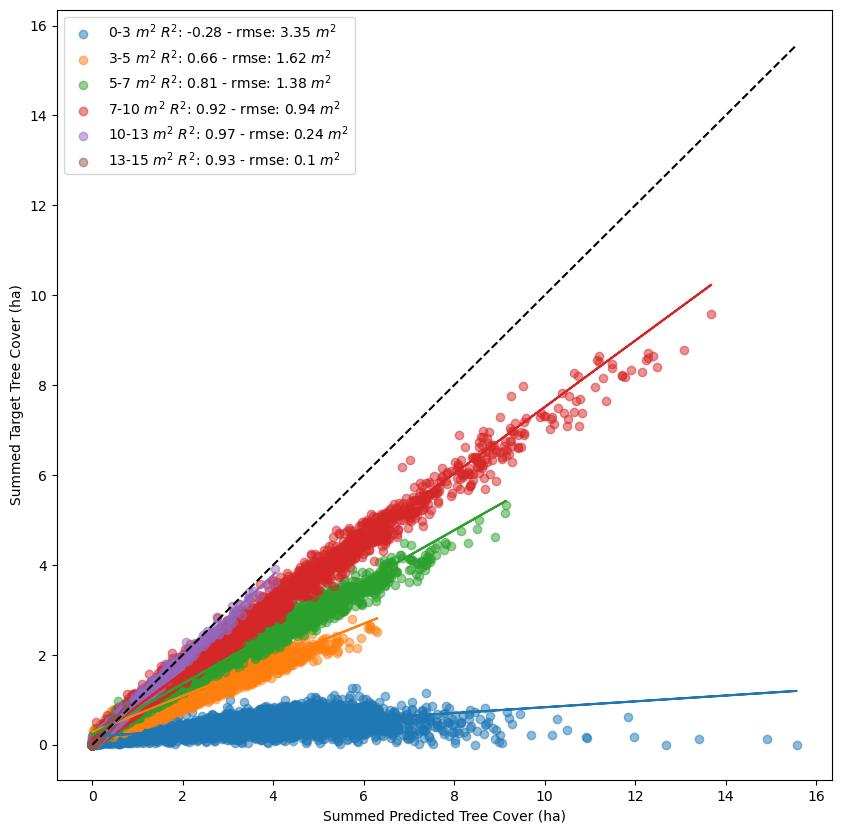

In [161]:
# plot means
import sklearn.metrics
plt.figure(figsize=(10, 10))

# Calculate R² and RMSE, and round the results
r2_10 = round(sklearn.metrics.r2_score(fl_pred_10, fl_area_10), 2)
rmse_10 = str(round(rmse(fl_pred_10, fl_area_10), 2))

r2_10_25 = str(round(sklearn.metrics.r2_score(fl_pred_10_25, fl_area_10_25), 2))
rmse_10_25 = str(round(rmse(fl_pred_10_25, fl_area_10_25), 2))

r2_25_50 = round(sklearn.metrics.r2_score(fl_pred_25_50, fl_area_25_50), 2)
rmse_25_50 = str(round(rmse(fl_pred_25_50, fl_area_25_50), 2))

r2_50_100 = round(sklearn.metrics.r2_score(fl_pred_50_100, fl_area_50_100), 2)
rmse_50_100 = str(round(rmse(fl_pred_50_100, fl_area_50_100), 2))

r2_100_150 = round(sklearn.metrics.r2_score(fl_pred_100_150, fl_area_100_150), 2)
rmse_100_150 = str(round(rmse(fl_pred_100_150, fl_area_100_150), 2))

r2_150_214 = round(sklearn.metrics.r2_score(fl_pred_150_214, fl_area_150_214), 2)
rmse_150_214 = str(round(rmse(fl_pred_150_214, fl_area_150_214), 2))

plt.scatter(mean_pred_10, mean_area_10, label=f"0-3 $m^2$ $R^2$: {r2_10} - rmse: {rmse_10} $m^2$", alpha=0.5)
plt.scatter(mean_pred_10_25, mean_area_10_25, label=f"3-5 $m^2$ $R^2$: {r2_10_25} - rmse: {rmse_10_25} $m^2$", alpha=0.5)
plt.scatter(mean_pred_25_50, mean_area_25_50, label=f"5-7 $m^2$ $R^2$: {r2_25_50} - rmse: {rmse_25_50} $m^2$", alpha=0.5)
plt.scatter(mean_pred_50_100, mean_area_50_100, label=f"7-10 $m^2$ $R^2$: {r2_50_100} - rmse: {rmse_50_100} $m^2$", alpha=0.5)
plt.scatter(mean_pred_100_150, mean_area_100_150, label=f"10-13 $m^2$ $R^2$: {r2_100_150} - rmse: {rmse_100_150} $m^2$", alpha=0.5)
plt.scatter(mean_pred_150_214, mean_area_150_214, label=f"13-15 $m^2$ $R^2$: {r2_150_214} - rmse: {rmse_150_214} $m^2$", alpha=0.5)

# add best fit lines

m, b = np.polyfit(mean_pred_10, mean_area_10, 1)
plt.plot(mean_pred_10, m*mean_pred_10 + b)

m, b = np.polyfit(mean_pred_10_25, mean_area_10_25, 1)
plt.plot(mean_pred_10_25, m*mean_pred_10_25 + b)

m, b = np.polyfit(mean_pred_25_50, mean_area_25_50, 1)
plt.plot(mean_pred_25_50, m*mean_pred_25_50 + b)

m, b = np.polyfit(mean_pred_50_100, mean_area_50_100, 1)
plt.plot(mean_pred_50_100, m*mean_pred_50_100 + b)

m, b = np.polyfit(mean_pred_100_150, mean_area_100_150, 1)
plt.plot(mean_pred_100_150, m*mean_pred_100_150 + b)

m, b = np.polyfit(mean_pred_150_214, mean_area_150_214, 1)
plt.plot(mean_pred_150_214, m*mean_pred_150_214 + b)

# 1-1 line 
plt.plot([0, np.max(mean_pred_10)], [0, np.max(mean_pred_10)], color="black", linestyle="--")
plt.ylabel("Summed Target Tree Cover (ha)")
plt.xlabel("Summed Predicted Tree Cover (ha)")
plt.legend()
plt.savefig("minmum_tree_detectable_2020.png", dpi=1000)
#plt.show()


In [162]:
# plot means
import sklearn.metrics
plt.figure(figsize=(10, 10))

# Calculate R² and RMSE, and round the results
r2_10 = round(sklearn.metrics.r2_score(fl_pred_10, fl_area_10), 2)
rmse_10 = str(round(rmse(fl_pred_10, fl_area_10), 2))

r2_10_25 = str(round(sklearn.metrics.r2_score(fl_pred_10_25, fl_area_10_25), 2))
rmse_10_25 = str(round(rmse(fl_pred_10_25, fl_area_10_25), 2))

r2_25_50 = round(sklearn.metrics.r2_score(fl_pred_25_50, fl_area_25_50), 2)
rmse_25_50 = str(round(rmse(fl_pred_25_50, fl_area_25_50), 2))

r2_50_100 = round(sklearn.metrics.r2_score(fl_pred_50_100, fl_area_50_100), 2)
rmse_50_100 = str(round(rmse(fl_pred_50_100, fl_area_50_100), 2))

r2_100_150 = round(sklearn.metrics.r2_score(fl_pred_100_150, fl_area_100_150), 2)
rmse_100_150 = str(round(rmse(fl_pred_100_150, fl_area_100_150), 2))

r2_150_214 = round(sklearn.metrics.r2_score(fl_pred_150_214, fl_area_150_214), 2)
rmse_150_214 = str(round(rmse(fl_pred_150_214, fl_area_150_214), 2))

plt.scatter(fl_pred_10, fl_area_10, label=f"0-3 $m^2$ $R^2$: {r2_10} - rmse: {rmse_10} $m^2$", alpha=0.5)
plt.scatter(fl_pred_10_25, fl_area_10_25, label=f"3-5 $m^2$ $R^2$: {r2_10_25} - rmse: {rmse_10_25} $m^2$", alpha=0.5)
plt.scatter(fl_pred_25_50, fl_area_25_50, label=f"5-7 $m^2$ $R^2$: {r2_25_50} - rmse: {rmse_25_50} $m^2$", alpha=0.5)
plt.scatter(fl_pred_50_100, fl_area_50_100, label=f"7-10 $m^2$ $R^2$: {r2_50_100} - rmse: {rmse_50_100} $m^2$", alpha=0.5)
plt.scatter(fl_pred_100_150, fl_area_100_150, label=f"10-13 $m^2$ $R^2$: {r2_100_150} - rmse: {rmse_100_150} $m^2$", alpha=0.5)
plt.scatter(fl_pred_150_214, fl_area_150_214, label=f"13-15 $m^2$ $R^2$: {r2_150_214} - rmse: {rmse_150_214} $m^2$", alpha=0.5)

# add best fit lines

m, b = np.polyfit(mean_pred_10, mean_area_10, 1)
plt.plot(mean_pred_10, m*mean_pred_10 + b)

m, b = np.polyfit(mean_pred_10_25, mean_area_10_25, 1)
plt.plot(mean_pred_10_25, m*mean_pred_10_25 + b)

m, b = np.polyfit(mean_pred_25_50, mean_area_25_50, 1)
plt.plot(mean_pred_25_50, m*mean_pred_25_50 + b)

m, b = np.polyfit(mean_pred_50_100, mean_area_50_100, 1)
plt.plot(mean_pred_50_100, m*mean_pred_50_100 + b)

m, b = np.polyfit(mean_pred_100_150, mean_area_100_150, 1)
plt.plot(mean_pred_100_150, m*mean_pred_100_150 + b)

m, b = np.polyfit(mean_pred_150_214, mean_area_150_214, 1)
plt.plot(mean_pred_150_214, m*mean_pred_150_214 + b)

# 1-1 line 
plt.plot([0, np.max(mean_pred_10)], [0, np.max(mean_pred_10)], color="black", linestyle="--")
plt.ylabel("Summed Target Tree Cover (ha)")
plt.xlabel("Summed Predicted Tree Cover (ha)")
plt.legend()
#plt.savefig("minmum_tree_detectable_2020.png", dpi=1000)
plt.show()


: 

In [ ]:
plt.scatter(fl_pred_10, fl_area_10, label=f"0-3 $m^2$ $R^2$: {r2_10} - rmse: {rmse_10} $m^2$", alpha=0.5)
plt.show()

In [58]:
pred_10_mean = np.array(pred_10_list)
area_10_mean = np.array(area_10_list)
#remoe where both area and pred are 0
mask = (area_10_mean != 0) & (pred_10_mean != 0)
pred_10_mean = pred_10_mean[mask]
area_10_mean = area_10_mean[mask]

pred_10_25_mean = np.array(pred_10_25_list)
area_10_25_mean = np.array(area_10_25_list)

mask = (area_10_25_mean != 0) & (pred_10_25_mean != 0)
pred_10_25_mean = pred_10_25_mean[mask]
area_10_25_mean = area_10_25_mean[mask]

pred_25_50_mean = np.array(pred_25_50_list)
area_25_50_mean = np.array(area_25_50_list)

mask = (area_25_50_mean != 0) & (pred_25_50_mean != 0)
pred_25_50_mean = pred_25_50_mean[mask]
area_25_50_mean = area_25_50_mean[mask]

pred_50_100_mean = np.array(pred_50_100_list)
area_50_100_mean = np.array(area_50_100_list)

mask = (area_50_100_mean != 0) & (pred_50_100_mean != 0)
pred_50_100_mean = pred_50_100_mean[mask]
area_50_100_mean = area_50_100_mean[mask]

pred_100_150_mean = np.array(pred_100_150_list)
area_100_150_mean = np.array(area_100_150_list)

mask = (area_100_150_mean != 0) & (pred_100_150_mean != 0)
pred_100_150_mean = pred_100_150_mean[mask]
area_100_150_mean = area_100_150_mean[mask]

pred_150_214_mean = np.array(pred_150_214_list)
area_150_214_mean = np.array(area_150_214_list)

mask = (area_150_214_mean != 0) & (pred_150_214_mean != 0)
pred_150_214_mean = pred_150_214_mean[mask]
area_150_214_mean = area_150_214_mean[mask]

import sklearn.metrics
print(sklearn.metrics.r2_score(area_10_mean, pred_10_mean))
print(sklearn.metrics.r2_score(area_10_25_mean, pred_10_25_mean))
print(sklearn.metrics.r2_score(area_25_50_mean, pred_25_50_mean))
print(sklearn.metrics.r2_score(area_50_100_mean, pred_50_100_mean))
print(sklearn.metrics.r2_score(area_100_150_mean, pred_100_150_mean))
print(sklearn.metrics.r2_score(area_150_214_mean, pred_150_214_mean))


-144.70473826631732
-74.80002362763697
-33.78449773449988
-9.809194891849707
-15.16906727533512
-26.355282706696624


In [ ]:
preds_mean = np.array(preds).mean(axis=(1,2))
areas_mean = np.array(areas).mean(axis=(1,2))

In [ ]:
print

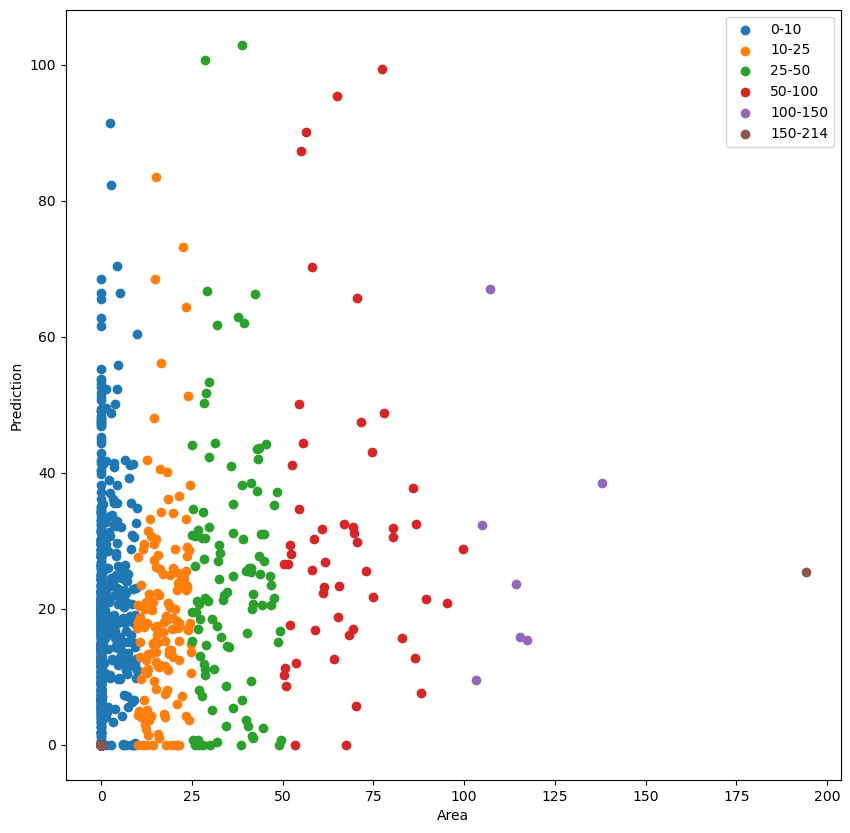

In [44]:
# plot subset of data
plt.figure(figsize=(10, 10))
plt.scatter(area_10_mean[:1000], pred_10_mean[:1000], label="0-10")
plt.scatter(area_10_25_mean[:1000], pred_10_25_mean[:1000], label="10-25")
plt.scatter(area_25_50_mean[:1000], pred_25_50_mean[:1000], label="25-50")
plt.scatter(area_50_100_mean[:1000], pred_50_100_mean[:1000], label="50-100")
plt.scatter(area_100_150_mean[:1000], pred_100_150_mean[:1000], label="100-150")
plt.scatter(area_150_214_mean[:1000], pred_150_214_mean[:1000], label="150-214")
plt.legend()
plt.xlabel("Area")
plt.ylabel("Prediction")

plt.show()

In [43]:
print(sklearn.metrics.r2_score(area_10_mean, pred_10_mean))
print(sklearn.metrics.r2_score(area_10_25_mean, pred_10_25_mean))
print(sklearn.metrics.r2_score(area_25_50_mean, pred_25_50_mean))
print(sklearn.metrics.r2_score(area_50_100_mean, pred_50_100_mean))
print(sklearn.metrics.r2_score(area_100_150_mean, pred_100_150_mean))
print(sklearn.metrics.r2_score(area_150_214_mean, pred_150_214_mean))

-121.71531717192217
-4.094940130737661
-0.40058740777603274
0.5943557242799657
0.7786496992208916
0.7010186278991579


In [2]:
predictions_rst = "/home/rene1337/RSCPH/ls789_102022.vrt"
area_shp = "/mnt/sdc/tree_density_and_coverage/shapefiles/nasa_validation/senegal_cutlines_intersection_with_tiles.gpkg"
early_dir = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_early"
late_dir = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_late"
polys_early = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/polygons_early"
polys_late = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/polygons_late"

In [3]:
gdf = gpd.read_file(area_shp.replace(".gpkg", "_sorted_102022.gpkg"))

In [8]:
# Function to read list of .gpkg files and merge into one geodataframe
def read_gpkg_files(files, bounds):
    gdfs = []
    for file in files:
        gdfs.append(gpd.read_file(file, bbox=bounds, engine="pyogrio"))
    gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
    return gdf


# polygonize raster
def polygonize(array, transform):
    results = (
        {'properties': {'raster_val': v}, 'geometry': s}
        for i, (s, v) 
        in enumerate(shapes(array, mask=None, transform=transform))
    )
    return results


def downsample(high_res, low_res):
    high_res = high_res[:high_res.shape[0] - high_res.shape[0] % low_res.shape[0], :high_res.shape[1] - high_res.shape[1] % low_res.shape[1]]
    kernel_size = (high_res.shape[0] // low_res.shape[0], high_res.shape[1] // low_res.shape[1])
    stride = kernel_size
    pool = nn.AvgPool2d(kernel_size=kernel_size, stride=stride, divisor_override=1)
    high_res_tensor = torch.tensor(high_res).unsqueeze(0).unsqueeze(0).float()
    high_res_downsampled = pool(high_res_tensor).squeeze(0).squeeze(0).to("cpu").numpy()*0.5
    return high_res_downsampled


# function to rasterize

def rasterize(gdf, transform, shape):
    out_shape = (shape[0], shape[1])
    out_array = np.zeros(out_shape, dtype=np.uint8)
    for _, row in gdf.iterrows():
        geom = row.geometry
        value = row["raster_val"]
        mask = rasterio.features.geometry_mask([geom], transform=transform, invert=True, out_shape=out_shape)
        out_array[mask] = value
    return out_array

In [9]:
for index, row in tqdm.tqdm(gdf.iterrows(), total=len(gdf)):
    #try:
        bounds = row["geometry"].bounds
        
        early_raster = f"{early_dir}/{row['location']}"
        late_raster = f"{late_dir}/{row['location_2']}"
        early_polys = glob.glob(f"{polys_early}/{row['location'].replace('.tif', '')}/vrtdata/*.gpkg")
        late_polys = glob.glob(f"{polys_late}/{row['location_2'].replace('.tif', '')}/vrtdata/*.gpkg")
        
        early_gdf = read_gpkg_files(early_polys, bounds)
            
        print(early_gdf.head())
            
        early = rasterio.open(early_raster)
        late = rasterio.open(late_raster)
        early_window = from_bounds(*bounds, early.transform)
        late_window = from_bounds(*bounds, late.transform)
        early_data = np.where(early.read(1, window=early_window) >= 1, 1, 0)
        late_data = np.where(late.read(1, window=late_window) >= 1, 1, 0)

        trend_raster = rasterio.open(predictions_rst)
        trend_window = from_bounds(*bounds, trend_raster.transform)
        trend_data = trend_raster.read(3, window=trend_window)

        early_data = downsample(early_data, trend_data) 
        early_data = np.where(early_data >= 225, 225, early_data)
        late_data = downsample(late_data, trend_data)
        late_data = np.where(late_data >= 225, 225, late_data)
        
        early_data = early_data/225
        late_data = late_data/225
        
        change = late_data - early_data

        results_dict = {"trend": trend_data, "early": early_data, "late": late_data, "change": change}
        #results.append(results_dict)
        
        break
        
'''except Exception as e:
        print(e)
        with open("error_log_minimum_tree.txt", "a") as f:
            f.write(f"{datetime.datetime.now()} - {row['location']} - {e}\n")
        
        break
    '''

  0%|          | 0/36157 [00:00<?, ?it/s]

                                            geometry
0  POLYGON ((-4369990.500 1733000.000, -4369990.5...
1  POLYGON ((-4369490.500 1733000.000, -4369490.5...
2  POLYGON ((-4369071.500 1733000.000, -4369071.5...
3  POLYGON ((-4369147.500 1733000.000, -4369147.5...
4  POLYGON ((-4369111.500 1733000.000, -4369111.5...


  0%|          | 0/36157 [00:09<?, ?it/s]


'except Exception as e:\n        print(e)\n        with open("error_log_minimum_tree.txt", "a") as f:\n            f.write(f"{datetime.datetime.now()} - {row[\'location\']} - {e}\n")\n        \n        break\n    '

In [ ]:
/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/polygons_early/det_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06_Senegal_2002_2016_102022_GE01-QB02-WV02-WV03_PV_354_005_mosaic/vrtdata/polygons_det_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06_Senegal_2002_2016_102022_GE01-QB02-WV02-WV03_PV_354_005_mosaic.vrt

/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/polygons_early/det_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06_Senegal_2002_2016_102022_GE01-QB02-WV02-WV03_PV_354_005_mosaic/polygons_det_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06_Senegal_2002_2016_102022_GE01-QB02-WV02-WV03_PV_354_005_mosaic.vrt

In [40]:
test_rst = "/home/rene1337/RSCPH/ls789.vrt"
test_shp = "/mnt/sda/029_011_32_features.gpkg"

In [41]:
trees = gpd.read_file(test_shp)
trees = trees.to_crs(epsg=4326)

In [42]:
bounds = trees.total_bounds
bounds

array([ 7.40774882, 13.59278905,  7.56011909, 13.74177751])

In [43]:
src = rasterio.open(test_rst)
window = from_bounds(*bounds, transform=src.transform)
window_transform = src.window_transform(window)
rst = src.read(window=window)


(5, 1106, 1131)


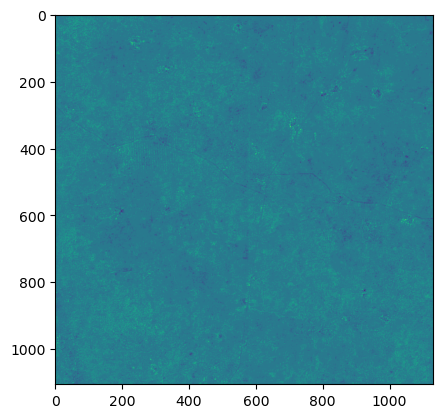

In [44]:
print(rst.shape)
plt.imshow(rst[-1])

In [45]:
sig_diff = rst[-1]
pos_sig_diff = np.where(sig_diff > 0, 1, 0).astype(np.int16)


In [46]:
poly = list(polygonize(pos_sig_diff, window_transform))

In [53]:
# convert list of dicts `poly` to geodataframe
gdf = gpd.GeoDataFrame.from_features(poly).set_crs(epsg=4326)
#gdf = gdf.set_crs(epsg=4326)
gdf = gdf[gdf['raster_val'] == 1]

In [76]:
# extract trees if inttersect with polygon
trees_in_poly = gpd.overlay(trees, gdf, how='intersection', keep_geom_type=True)
trees_out_poly = gpd.overlay(trees, trees_in_poly, how='difference', keep_geom_type=True)


In [93]:
# change categorical strings to integers
import pandas as pd
trees_in_poly = trees_in_poly.to_crs(epsg=3857)
trees_out_poly = trees_out_poly.to_crs(epsg=3857)
trees = trees.to_crs(epsg=3857)
trees_in_poly["area"] = trees_in_poly.geometry.area
trees_out_poly["area"] = trees_out_poly.geometry.area
trees["area"] = trees.geometry.area
trees_out_poly["area_class"] = pd.cut(trees_out_poly["area"], bins=[0, 5, 10, 15, 30, 100], labels=["0-5", "5-10", "10-15", "15-30", "30-100"])
trees_in_poly["area_class"] = pd.cut(trees_in_poly["area"], bins=[0, 5, 10, 15, 30, 100], labels=["0-5", "5-10", "10-15", "15-30", "30-100"])
trees["area_class"] = pd.cut(trees["area"], bins=[0, 5, 10, 15, 30, 100], labels=["0-5", "5-10", "10-15", "15-30", "30-100"])
trees_in_poly['area_class_int'] = trees_in_poly['area_class'].astype('category').cat.codes
trees_out_poly['area_class_int'] = trees_out_poly['area_class'].astype('category').cat.codes

In [70]:
gdf.to_file("/mnt/sda/029_011_32_features_rasterized.gpkg", driver="GPKG")
trees_in_poly.to_file("/mnt/sda/029_011_32_trees_in_poly.shp")
trees_out_poly.to_file("/mnt/sda/029_011_32_trees_out_poly.shp")

In [55]:
print(trees_in_poly.head())
print(trees_out_poly.head())

          Lat       Long  RasterX  RasterY      NDVI       PAN   Area  Height  \
0  1519634.75  328160.75      641        2  0.115939  0.320879   8.25     0.0   
1  1519634.75  329657.75     3635        2  0.110786  0.315339   7.00     0.0   
2  1519635.25  331558.25     7436        1  0.112760  0.325980   6.25     0.0   
3  1519607.00  331524.75     7369       58  0.112621  0.322063  21.75     0.0   
4  1519635.00  335715.00    15750        2  0.112135  0.305081   9.25     0.0   

   Leaf_Mass   Wood_Mass  Root_Mass  raster_val  \
0   1.974515   40.771458   9.910931         1.0   
1   1.690805   33.992218   8.173612         1.0   
2   1.519241   29.985065   7.156179         1.0   
3   4.930962  119.213348  30.899658         1.0   
4   2.199737   46.275452  11.334392         1.0   

                                            geometry  
0  POLYGON ((7.41073 13.74089, 7.41073 13.74088, ...  
1  POLYGON ((7.42456 13.74096, 7.42456 13.74095, ...  
2  POLYGON ((7.44215 13.74108, 7.44213 13

5-10      43427
0-5       41654
15-30     38639
10-15     26098
30-100    19244
Name: area_class, dtype: int64
15.129009351930064
15-30     30395
30-100    22869
0-5       22564
5-10      21482
10-15     15663
Name: area_class, dtype: int64
20.574277243326932


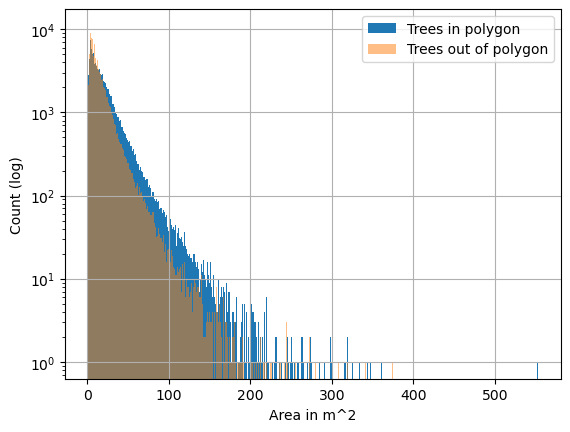

In [86]:


#split into area classes

print(trees_out_poly["area_class"].value_counts())
#average area of trees
print(trees_out_poly["area"].mean())
# see distribution of area
trees_in_poly["area"].hist(bins=500, log=True)

print(trees_in_poly["area_class"].value_counts())
print(trees_in_poly["area"].mean())
#reverse distribution
trees_out_poly["area"].hist(bins=500, log=True, alpha=0.5)
plt.legend(["Trees in polygon", "Trees out of polygon"])
plt.xlabel("Area in m^2")
plt.ylabel("Count (log)")
plt.show()

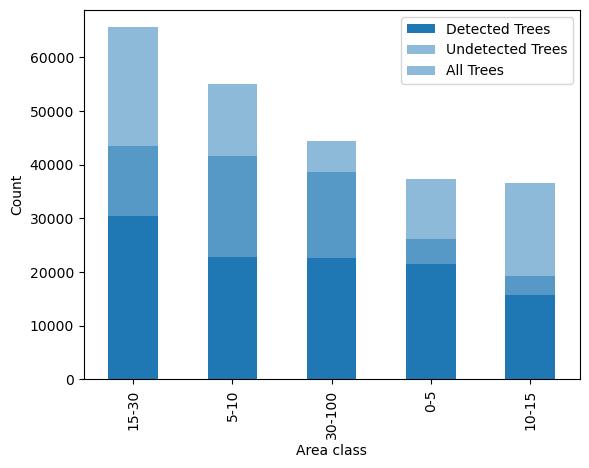

In [95]:
# bar chart of area class 
trees_in_poly["area_class"].value_counts().plot(kind='bar')
trees_out_poly["area_class"].value_counts().plot(kind='bar', alpha=0.5)
trees["area_class"].value_counts().plot(kind='bar', alpha=0.5)
plt.xlabel("Area class")
legend = plt.legend(["Detected Trees", "Undetected Trees", "All Trees"])
plt.ylabel("Count")
plt.show()


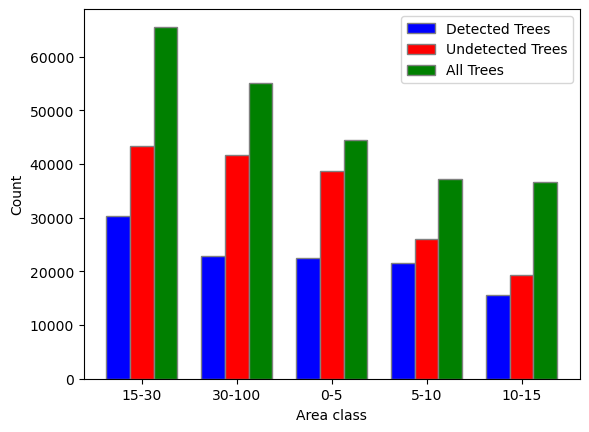

In [96]:
#plot bars next to each other
fig, ax = plt.subplots()
barWidth = 0.25
bars1 = trees_in_poly["area_class"].value_counts()
bars2 = trees_out_poly["area_class"].value_counts()
bars3 = trees["area_class"].value_counts()
r1 = np.arange(len(bars1))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
plt.bar(r1, bars1, color='b', width=barWidth, edgecolor='grey', label='Detected Trees')
plt.bar(r2, bars2, color='r', width=barWidth, edgecolor='grey', label='Undetected Trees')
plt.bar(r3, bars3, color='g', width=barWidth, edgecolor='grey', label='All Trees')
plt.xlabel("Area class")
plt.ylabel("Count")
plt.xticks([r + barWidth for r in range(len(bars1))], bars1.index)
plt.legend()
plt.show()


<Axes: >

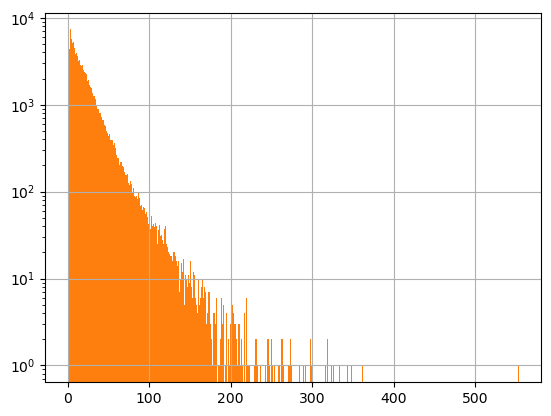

In [58]:
# see distribution of area
trees_in_poly["area"].hist(bins=500)
#reverse distribution
trees_in_poly["area"].hist(bins=500, log=True)


In [4]:
from osgeo import gdal
import os
import glob

In [6]:
in_dir = "/mnt/sdc/ls89gf"
years = list(range(1999, 2024))

for year in years:
    preds = []
    tiles = os.listdir(in_dir)
    tiles = [tile for tile in tiles if "coords" in tile]
    for tile in tiles:
        
        files = os.listdir(f"{in_dir}/{tile}")
        for file in files:
            if str(year) in file:
                raster = glob.glob(f"{in_dir}/{tile}/{file}/*.tif")
                
                if len(raster) > 0:
                    preds.append(raster[0])
                
    vrt = gdal.BuildVRT(f"/mnt/sdc/ls89gf/{year}_silver_sweep_9.vrt", preds)
    vrt = None
    
    print(f"{year} done")


1999 done
2000 done
2001 done
2002 done
2003 done
2004 done
2005 done
2006 done
2007 done
2008 done
2009 done


ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.


2010 done
2011 done


ERROR 1: No input dataset specified.
ERROR 1: No input dataset specified.
Warning 1: gdalbuildvrt does not support heterogeneous projection: expected WGS 84, got WGS 84 / UTM zone 32N. Skipping /mnt/sdc/ls89gf/coords_11_16_2_Landsat/2012-10-29/coords_11_16_2_Landsat_2012_10_29_silver_sweep_9.tif
Warning 1: gdalbuildvrt does not support heterogeneous projection: expected WGS 84, got WGS 84 / UTM zone 32N. Skipping /mnt/sdc/ls89gf/coords_12_15_6_Landsat/2012-10-31/coords_12_15_6_Landsat_2012_10_31_silver_sweep_9.tif
Warning 1: gdalbuildvrt does not support heterogeneous projection: expected WGS 84, got WGS 84 / UTM zone 32N. Skipping /mnt/sdc/ls89gf/coords_12_15_4_Landsat/2012-10-31/coords_12_15_4_Landsat_2012_10_31_silver_sweep_9.tif
Warning 1: gdalbuildvrt does not support heterogeneous projection: expected WGS 84, got WGS 84 / UTM zone 32N. Skipping /mnt/sdc/ls89gf/coords_12_16_3_Landsat/2012-10-28/coords_12_16_3_Landsat_2012_10_28_silver_sweep_9.tif
Warning 1: gdalbuildvrt does not s

2012 done
2013 done
2014 done
2015 done
2016 done
2017 done
2018 done
2019 done
2020 done
2021 done
2022 done
2023 done
